In [20]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

# Data and Overview

In [2]:
df_complete = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Completed operations.csv",
    sep=";"
)
df_cancelled = pd.read_csv(
    "../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv",
    sep=";"
)

/var/folders/hs/9s0b5rgj539chsrz2hkbmzrr0000gn/T/ipykernel_57150/3917172957.py:1: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv(


In [3]:
df_complete.describe()

,Case-ID Anonymous,Patient Alder,Operationsgang ID,Forsinkelse (minutter),Overskredet (minutter),Staff.Anæstesiolog,Staff.Anæstesisygeplejerske,Staff.Gulvassistent,Staff.Operationssygeplejerske,Staff.Preprocedure Nurse,...,Ressource.Olympus Exera II (anæstesisøjle),Ressource.Sonostar,Ressource.COP3589 A O bøjejern rekonstruktionsskinner,Ressource.BMAC-centrifuge,Ressource.Benchbord,Ressource.Diodelaser næse,Ressource.Øre optik 30°,Ressource.Endoskop,Ressource.Flexcystoskop,Ressource.Kasette
count,133158.000000,133158.000000,133158.000000,132491.000000,132537.000000,74832.0,79227.0,113625.0,119226.0,80560.0,...,2.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,2.0,0.0
mean,60156.037437,53.788244,40663.550909,20.511642,25.346198,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
std,34927.061620,24.889920,52262.972747,50.977296,68.894706,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN
min,1.000000,0.000000,618.000000,-3045.000000,-3003.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
25%,29928.250000,34.000000,622.000000,0.000000,-10.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
50%,60097.500000,61.000000,625.000000,14.000000,23.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
75%,90338.750000,74.000000,107621.000000,40.000000,57.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
max,120868.000000,107.000000,133218.000000,1585.000000,1560.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


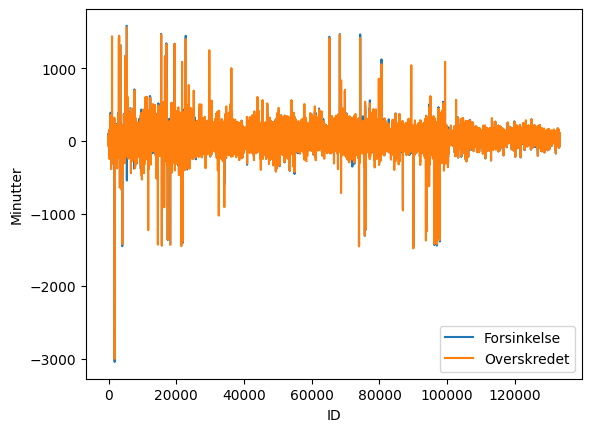

In [4]:
forsinkelse_col = df_complete['Forsinkelse (minutter)']
overskredet_col = df_complete['Overskredet (minutter)']
plt.plot(forsinkelse_col, label='Forsinkelse')
plt.plot(overskredet_col, label='Overskredet')
plt.legend()
plt.ylabel('Minutter')
plt.xlabel('ID')
plt.show()

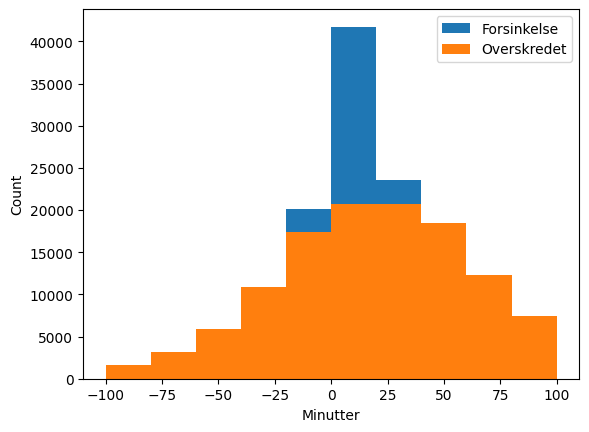

In [5]:
forsinkelse_col_mid = df_complete[df_complete['Forsinkelse (minutter)'].between(-100,100)]['Forsinkelse (minutter)']
overskredet_col_mid = df_complete[df_complete['Overskredet (minutter)'].between(-100,100)]['Overskredet (minutter)']
plt.hist(forsinkelse_col_mid, label='Forsinkelse')
plt.hist(overskredet_col_mid, label='Overskredet')
plt.legend()
plt.ylabel('Count')
plt.xlabel('Minutter')
plt.show()

# Compute confidence intervals for observations

In [6]:
# Change to 2.576 for 99% CI
mean_forsinkelse = forsinkelse_col.mean()
se_forsinkelse = forsinkelse_col.std(ddof=1)
ci_lower_forsinkelse = mean_forsinkelse - 1.96 * se_forsinkelse 
ci_upper_forsinkelse = mean_forsinkelse + 1.96 * se_forsinkelse

mean_overskredet = overskredet_col.mean()
se_overskredet = overskredet_col.std(ddof=1)
ci_lower_overskredet = mean_overskredet - 1.96 * se_overskredet
ci_upper_overskredet = mean_overskredet + 1.96 * se_overskredet

print(f"{'Forsinkelse 95% CI:':20}{np.round((ci_lower_forsinkelse,ci_upper_forsinkelse), 3)}")
print(f"{'Overskredet 95% CI:':20}{np.round((ci_lower_overskredet,ci_upper_overskredet), 3)}")

Forsinkelse 95% CI: [-79.404 120.427]
Overskredet 95% CI: [-109.687  160.38 ]


# Delay

In [7]:
frac_delay = len(df_complete[df_complete['Forsinkelse (minutter)'] > 0]) / len(df_complete)
frac_delay_reason = len(df_complete[(df_complete['Forsinkelse (minutter)'] > 0) & 
                                    (df_complete['Forsinkelsesårsag'].notna())]) / len(df_complete['Forsinkelse (minutter)'] > 0)

# Reserve 50 characters for the text so numbers align
print(f"{'Fraction of operations delayed:':50}{frac_delay}")
print(f"{'Fraction of delayed operations with reason:':50}{frac_delay_reason}")

Fraction of operations delayed:                   0.726685591552892
Fraction of delayed operations with reason:       0.024624881719461093


# Initial Cluster

### Set up features

In [8]:
# Convert to date time
daytime_vars = ['Dato', 'Pt ankommet til hospitalet', 'Planlagt stue klargøring start', 
            'Stue klargøring start', 'Stue klargjort', 'Patient på stuen', 
            'Patient på stuen (Planlagt)', 'Anæstesistart', 'Anæstesi melder klar',
            'Procedure start', 'Procedure slut', 'Patient klar til afgang', 
            'Patient forlader stuen (Planlagt)', 'Patient forlader stuen', 'Stue rengjort (Planlagt)',
            'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop', 
            'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling']
for var in daytime_vars:
    df_complete[var] = pd.to_datetime(df_complete[var], format='%Y-%m-%d %H:%M:%S,%f')

# Add staff amount
staff_columns = [col for col in df_complete.columns if col.startswith("Staff")]
df_complete['Staff amount'] = df_complete[staff_columns].sum(axis=1)

# Add ressource amount
ressource_columns = [col for col in df_complete.columns if col.startswith("Ressource")]
df_complete['Ressource amount'] = df_complete[ressource_columns].sum(axis=1)

# One hot encoding of "Speciale" and "Akut case" and "Operationsgang ID"
df_complete = pd.get_dummies(df_complete, columns=['Speciale'])
df_complete['Akut case (J/N)'] = df_complete['Akut case (J/N)'].replace({'Ja': 1, 'Nej': 0})
df_complete = pd.get_dummies(df_complete, columns=['Operationsgang ID'])

In [9]:
# Add month variable, where sine and cosine are used to ensure similar features for close months
months = df_complete['Dato'].dt.month
df_complete['Måned_sin'] = np.sin(2 * np.pi * months/12)
df_complete['Måned_cos'] = np.cos(2 * np.pi * months/12)

### Feature selection

In [10]:
daytime_cols_to_drop = ['Dato', 'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
                        'Stue klargøring start', 'Stue klargjort', 'Patient på stuen (Planlagt)', 
                        'Patient på stuen', 'Anæstesistart', 'Anæstesi melder klar', 'Procedure start', 
                        'Procedure slut', 'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
                        'Patient forlader stuen', 'Stue rengjort (Planlagt)', 'Stue rengøring start', 
                        'Stue rengjort', 'I opvågning', 'Anæstesistop','Klar til udskrivelse efter opvågning', 
                        'Patient forlader afdeling','Forsinkelsesårsag']
staff_cols_to_drop = [col for col in df_complete.columns if col.startswith("Staff.")]
ressource_cols_to_drop = [col for col in df_complete.columns if col.startswith("Ressource.")]
other_cols_to_drop = ['Case-ID Anonymous', 'Stue', 'Procedure - Tekst & ID', 
                      'Aktionsdiagnose - Kode & tekst', 'Aktionsdiagnose - Gruppe']
cols_to_drop = daytime_cols_to_drop + staff_cols_to_drop + ressource_cols_to_drop + other_cols_to_drop
df_cluster = df_complete.drop(columns=cols_to_drop)
print(f"Number of samples before row exclusion: {len(df_cluster)}")

Number of samples before row exclusion: 133158


### Exclude Outliers (baseret på forsinkelse og overskredet)

In [11]:
df_cluster = df_cluster[df_cluster['Forsinkelse (minutter)'].between(ci_lower_forsinkelse, ci_upper_forsinkelse)]
df_cluster = df_cluster[df_cluster['Overskredet (minutter)'].between(ci_lower_overskredet, ci_upper_overskredet)]
print(f"Number of samples after outlier exclusion: {len(df_cluster)}")

Number of samples after outlier exclusion: 124570


### Exclude cases with missing data

In [12]:
df_cluster_clean = df_cluster

# Change NaNs in Staff and Ressource columns to zeros (if they are included as features)
#df_cluster_clean[staff_columns] = df_cluster_clean[staff_columns].fillna(0)
#df_cluster_clean[ressource_columns] = df_cluster_clean[ressource_columns].fillna(0)

# Drop rows with NaN
df_cluster_clean = df_cluster_clean.dropna()
print(f"Number of samples after NaN/NaT exclusion: {len(df_cluster_clean)}")

Number of samples after NaN/NaT exclusion: 124570


In [13]:
df_cluster_clean

,Patient Alder,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Staff amount,Ressource amount,Speciale_Alloplastik,Speciale_Anæstesiologi,Speciale_Brystkirurgi,Speciale_Børnekirurgi,...,Operationsgang ID_618,Operationsgang ID_620,Operationsgang ID_622,Operationsgang ID_624,Operationsgang ID_625,Operationsgang ID_107621,Operationsgang ID_107622,Operationsgang ID_133218,Måned_sin,Måned_cos
0,29,0,95.0,36.0,5.0,1.0,False,False,False,False,...,False,False,False,False,False,True,False,False,1.000000e+00,6.123234e-17
1,60,0,8.0,30.0,4.0,1.0,False,False,False,False,...,False,False,False,False,False,True,False,False,5.000000e-01,8.660254e-01
2,60,0,8.0,30.0,4.0,1.0,False,False,False,False,...,False,False,False,False,False,True,False,False,5.000000e-01,8.660254e-01
3,12,0,16.0,-3.0,4.0,1.0,False,False,False,False,...,False,False,False,False,False,True,False,False,5.000000e-01,8.660254e-01
4,57,0,16.0,1.0,3.0,1.0,False,False,False,False,...,False,False,False,False,False,True,False,False,-8.660254e-01,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133153,59,0,47.0,51.0,4.0,0.0,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00
133154,58,0,35.0,40.0,4.0,0.0,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00
133155,70,0,52.0,52.0,4.0,0.0,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00
133156,87,0,42.0,50.0,4.0,0.0,False,False,False,False,...,False,False,False,False,True,False,False,False,-2.449294e-16,1.000000e+00


### Do K-Means Clustering 

In [14]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_clean)

# Perform clustering
k = 5
kmeans = KMeans(n_clusters=k, random_state=2026)
kmeans.fit(X_scaled)

# Assign cluster labels to final DataFrame
df_final = df_cluster_clean
df_final['cluster'] = kmeans.labels_

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Inspect results

In [15]:
# Count of rows per cluster
print(df_final['cluster'].value_counts())

cluster
2    41472
4    39166
1    35428
3     4580
0     3924
Name: count, dtype: int64


In [16]:
# Compare mean values per cluster
cluster_summary = df_final.groupby('cluster').mean()
cluster_summary

,Patient Alder,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Staff amount,Ressource amount,Speciale_Alloplastik,Speciale_Anæstesiologi,Speciale_Brystkirurgi,Speciale_Børnekirurgi,...,Operationsgang ID_618,Operationsgang ID_620,Operationsgang ID_622,Operationsgang ID_624,Operationsgang ID_625,Operationsgang ID_107621,Operationsgang ID_107622,Operationsgang ID_133218,Måned_sin,Måned_cos
cluster,,,,,,,,,,,,,,,,,,,,,
0,54.206932,0.338685,-2.085117,6.343017,6.298165,1.049185,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-0.011422,-0.001000
1,47.682116,0.275658,9.659620,14.620272,5.897426,1.264141,0.000000,0.003387,0.000028,0.10949,...,0.383369,0.367252,0.022525,0.13447,0.001637,0.000565,0.035396,0.054787,0.012003,0.011199
2,46.070530,0.192178,13.043282,14.506173,6.633946,2.099272,0.008632,0.000096,0.000145,0.00000,...,0.000024,0.000000,0.000121,0.00000,0.000000,0.905912,0.093943,0.000000,0.017013,0.029327
3,61.006769,0.224672,-8.449127,-2.850873,5.880568,1.659170,0.000000,0.000000,0.000000,0.00000,...,0.005240,0.000437,0.993668,0.00000,0.000000,0.000655,0.000000,0.000000,0.006638,-0.020707
4,66.443701,0.081755,39.960016,44.168462,4.513583,0.177986,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.948986,0.014528,0.036486,0.000000,0.019640,0.038613


In [17]:
print(cluster_summary[cluster_summary.index==0].Speciale_Øjenkirurgi)
spec_cols = [col for col in cluster_summary.columns if col.startswith("Speciale_")]
print(np.array(cluster_summary[spec_cols][cluster_summary.index==0]).sum())

cluster
0    0.0
Name: Speciale_Øjenkirurgi, dtype: float64
1.0


### PCA and Plotting

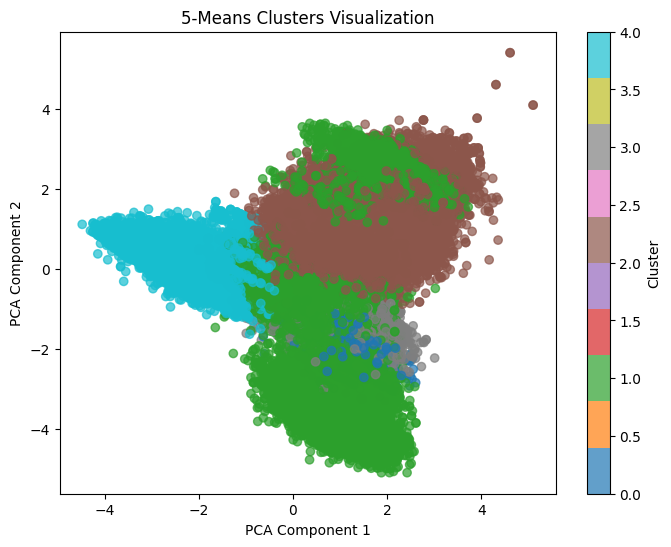

In [18]:
# Do PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_cluster_clean['cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('5-Means Clusters Visualization')
plt.colorbar(label='Cluster')
plt.show()

In [19]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

%matplotlib qt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=df_cluster_clean['cluster'], cmap='tab10', alpha=0.7)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()

# Use Random Forrest to Predict Importance of Features

In [25]:
# Make sure to exclude the 'cluster' column
numeric_cols = df_cluster_clean.drop(columns=['cluster']).select_dtypes(include=np.number).columns
X_scaled = scaler.fit_transform(df_cluster_clean[numeric_cols])

# Fit random forest
rf = RandomForestClassifier(random_state=2026)
rf.fit(X_scaled, kmeans.labels_)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
print(importances)

Patient Alder             0.196816
Forsinkelse (minutter)    0.187704
Overskredet (minutter)    0.174128
Staff amount              0.167850
Ressource amount          0.165125
Måned_sin                 0.044023
Måned_cos                 0.043172
Akut case (J/N)           0.021182
dtype: float64


In [26]:
top_features = importances.head(5).index
df_final.groupby('cluster')[top_features].mean().plot(kind='bar', figsize=(10,6))
plt.ylabel("Mean (scaled values)")
plt.title("Top Features by Cluster")
plt.show()